In [56]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [57]:
df = pd.read_csv('heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [58]:
df.dtypes

,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


In [59]:
X = df.drop('target', axis=1)
y = df['target']

In [60]:
X_encoded = pd.get_dummies(X, columns=['cp','restecg','slope','thal'])
X_encoded.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,cp_0,...,restecg_0,restecg_1,restecg_2,slope_0,slope_1,slope_2,thal_0,thal_1,thal_2,thal_3
0,63,1,145,233,1,150,0,2.3,0,False,...,True,False,False,True,False,False,False,True,False,False
1,37,1,130,250,0,187,0,3.5,0,False,...,False,True,False,True,False,False,False,False,True,False
2,41,0,130,204,0,172,0,1.4,0,False,...,True,False,False,False,False,True,False,False,True,False
3,56,1,120,236,0,178,0,0.8,0,False,...,False,True,False,False,False,True,False,False,True,False
4,57,0,120,354,0,163,1,0.6,0,True,...,False,True,False,False,False,True,False,False,True,False


Build a preliminary Classification Tree

In [61]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, random_state=42)

In [62]:
clf_dt = DecisionTreeClassifier(random_state=42)
clf_dt = clf_dt.fit(X_train, y_train)

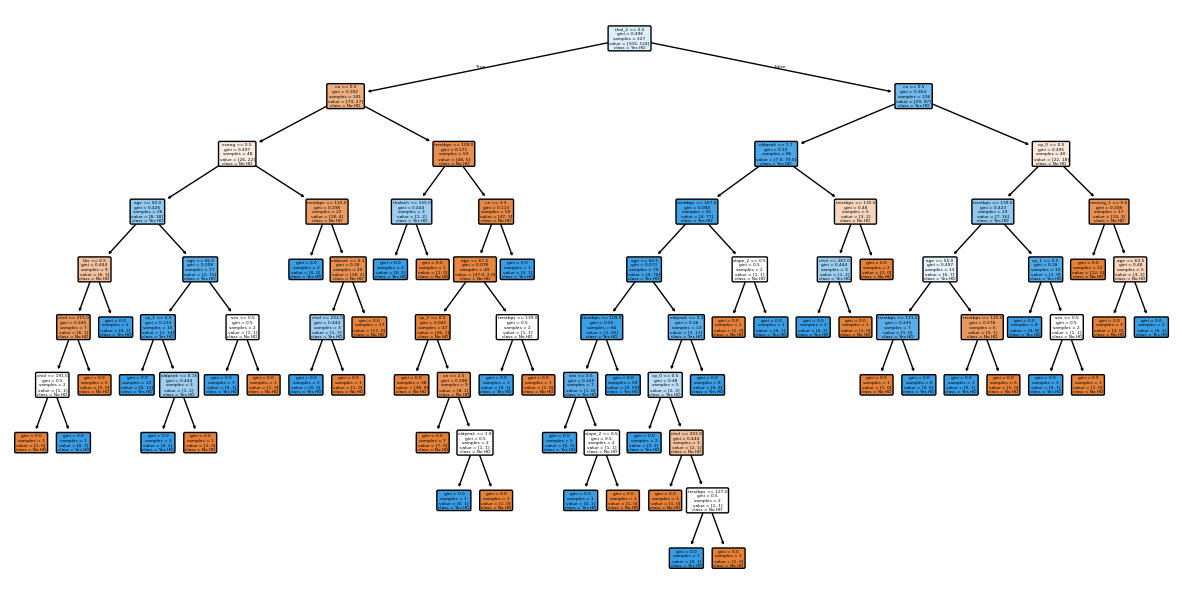

In [63]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(15, 7.5))
plot_tree(clf_dt, filled=True,rounded=True,class_names=["No HD", "Yes HD"],feature_names=X_encoded.columns);

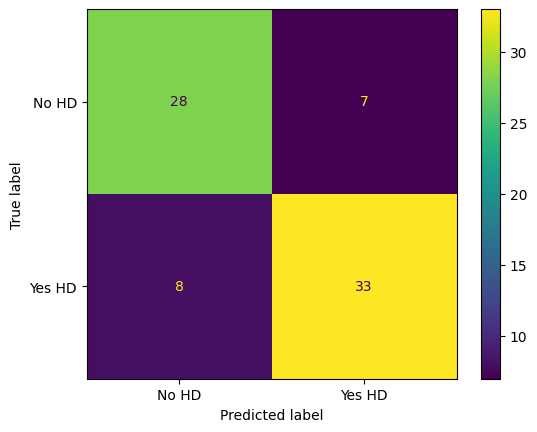

In [64]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create the ConfusionMatrixDisplay from the estimator
ConfusionMatrixDisplay.from_estimator(clf_dt, X_test, y_test, display_labels=["No HD", "Yes HD"])
plt.show()

In [65]:
path = clf_dt.cost_complexity_pruning_path(X_train, y_train) # Determine values for alpha
ccp_alphas = path.ccp_alphas                                 # extract different values for alpha
ccp_alphas = ccp_alphas[:-1]

In [66]:
clf_dts = []

In [67]:
for ccp_alpha in ccp_alphas:
    clf_dt = DecisionTreeClassifier(random_state=0, ccp_alpha=ccp_alpha)
    clf_dt.fit(X_train, y_train)
    clf_dts.append(clf_dt)

In [68]:
train_scores = [clf_dt.score(X_train, y_train) for clf_dt in clf_dts]
test_scores = [clf_dt.score(X_test, y_test) for clf_dt in clf_dts]

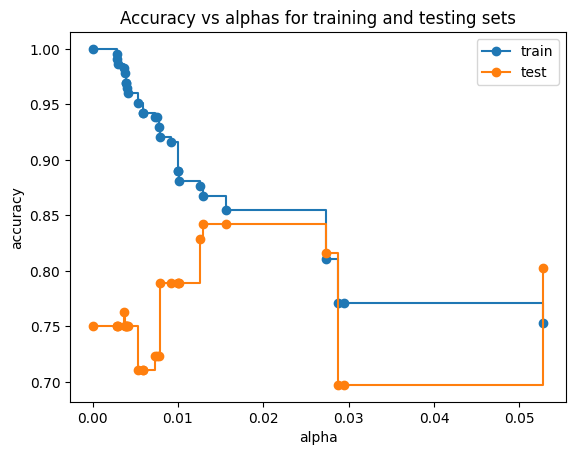

In [69]:
fig, ax = plt.subplots()
ax.set_xlabel('alpha')
ax.set_ylabel('accuracy')
ax.set_title('Accuracy vs alphas for training and testing sets')
ax.plot(ccp_alphas, train_scores, marker='o', label='train', drawstyle="steps-post")
ax.plot(ccp_alphas, test_scores, marker='o', label='test', drawstyle="steps-post")
ax.legend()
plt.show()

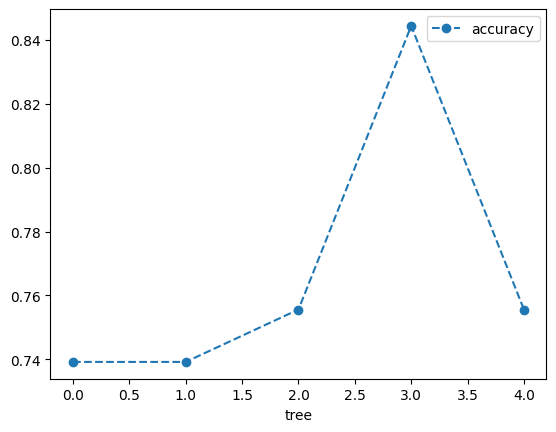

In [70]:
clf_dt = DecisionTreeClassifier(random_state=42, ccp_alpha=0.016)

scores = cross_val_score(clf_dt, X_train, y_train, cv=5)
df = pd.DataFrame(data={'tree': range(5), 'accuracy': scores})
df.plot(x='tree', y='accuracy', marker='o', linestyle='--')
plt.show()

<Axes: xlabel='alpha'>

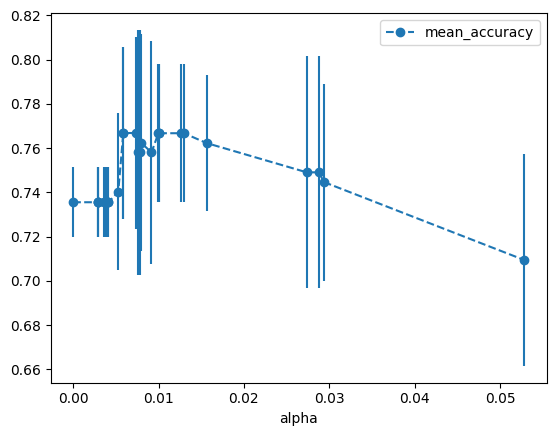

In [71]:
alpha_loop_values = []
for ccp_alpha in ccp_alphas:
    clf_dt = DecisionTreeClassifier(random_state=0, ccp_alpha=ccp_alpha)
    scores = cross_val_score(clf_dt, X_train, y_train, cv=5)
    alpha_loop_values.append([ccp_alpha, np.mean(scores), np.std(scores)])

alpha_results = pd.DataFrame(alpha_loop_values,
                            columns=['alpha', 'mean_accuracy', 'std'])
alpha_results.plot(x='alpha', y='mean_accuracy', yerr='std', marker='o', linestyle='--')

In [72]:
best_alpha = alpha_results.iloc[alpha_results['mean_accuracy'].idxmax(),]['alpha']

#Final tree

In [73]:
clf_dt_pruned = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha)
clf_dt_pruned.fit(X_train, y_train)

DecisionTreeClassifier(ccp_alpha=np.float64(0.007342143906020559),
                       random_state=42)

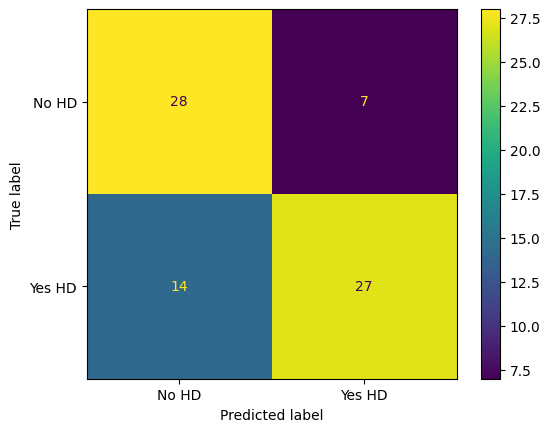

In [74]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(clf_dt_pruned, X_test, y_test, display_labels=["No HD", "Yes HD"])
plt.show()

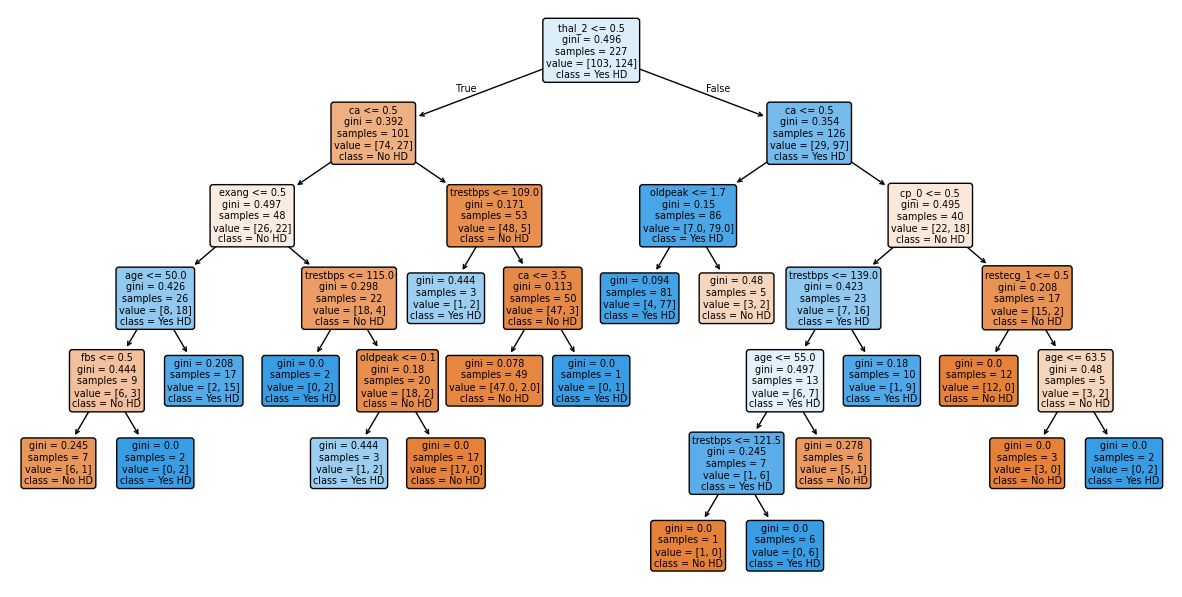

In [75]:
plt.figure(figsize=(15, 7.5))
plot_tree(clf_dt_pruned, filled=True,rounded=True,class_names=["No HD", "Yes HD"],feature_names=X_encoded.columns);